In [1]:
import pandas as pd
import numpy as np
import os
import glob
import gc
import shutil
from tqdm.notebook import tqdm # Use notebook version if in Jupyter

# --- CONFIGURATION ---
# Auto-detect paths
if os.path.exists("../data/processed"):
    DATA_DIR = "../data/processed"
elif os.path.exists("data/processed"):
    DATA_DIR = "data/processed"
else:
    DATA_DIR = "."

# Inputs (These are likely FOLDERS containing many .parquet parts)
SST_DIR = os.path.join(DATA_DIR, "nasa_sst_data_combined.parquet")
CHL_DIR = os.path.join(DATA_DIR, "chlorophyll_data_combined.parquet")

# Output (Will also be a FOLDER)
OUTPUT_DIR = os.path.join(DATA_DIR, "merged_impact_data.parquet")

def get_file_time_map(folder_path, var_name):
    """
    Scans a parquet folder and maps {timestamp: filepath}.
    This is critical because filenames might differ (part_0001 vs part_0002),
    but the internal 'time' column will match.
    """
    print(f"Indexing {os.path.basename(folder_path)}...")
    
    # Check if it's a folder or single file
    if os.path.isdir(folder_path):
        files = sorted(glob.glob(os.path.join(folder_path, "*.parquet")))
    else:
        files = [folder_path] # Handle single file case just in case

    time_map = {}
    
    for f in tqdm(files, desc=f"Indexing {var_name}"):
        try:
            # Read only the time column to be fast
            # We assume one file = one month (which is how we processed them)
            df = pd.read_parquet(f, columns=['time'])
            if not df.empty:
                t = df['time'].iloc[0] # Take the first timestamp found
                time_map[t] = f
        except Exception:
            pass
            
    return time_map

def merge_datasets():
    print(f"--- Starting RAM-Safe Data Merger ---")
    
    # 1. Setup Output
    if os.path.exists(OUTPUT_DIR):
        print(f"Cleaning existing output: {OUTPUT_DIR}")
        if os.path.isdir(OUTPUT_DIR):
            shutil.rmtree(OUTPUT_DIR)
        else:
            os.remove(OUTPUT_DIR)
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    # 2. Index Files by Time
    # This aligns the two datasets chronologically
    sst_map = get_file_time_map(SST_DIR, "SST")
    chl_map = get_file_time_map(CHL_DIR, "CHL")
    
    # 3. Find Overlapping Times
    common_times = sorted(list(set(sst_map.keys()) & set(chl_map.keys())))
    
    if not common_times:
        print("[CRITICAL] No overlapping dates found between SST and Chlorophyll data!")
        print("Check if your download ranges matched (2002-2025).")
        return

    print(f"\nFound {len(common_times)} overlapping time periods to merge.")
    
    # 4. Iterative Merge
    total_merged_rows = 0
    
    for i, t in enumerate(tqdm(common_times, desc="Merging")):
        sst_file = sst_map[t]
        chl_file = chl_map[t]
        
        try:
            # Load chunks
            df_sst = pd.read_parquet(sst_file)
            df_chl = pd.read_parquet(chl_file)
            
            # Optimization: Round coords to ensure matches between datasets
            # Satellite grids can drift slightly by 0.0001 deg, causing merge failures
            # Rounding to 2 decimal places (~1km precision) fixes this.
            df_sst['lat'] = df_sst['lat'].round(2)
            df_sst['lon'] = df_sst['lon'].round(2)
            df_chl['lat'] = df_chl['lat'].round(2)
            df_chl['lon'] = df_chl['lon'].round(2)
            
            # Merge
            df_merged = pd.merge(
                df_sst, 
                df_chl, 
                on=['time', 'lat', 'lon'], 
                how='inner' # Only keep pixels where we have BOTH temp and biology
            )
            
            if not df_merged.empty:
                # Add ML features now to save time later
                df_merged['month'] = df_merged['time'].dt.month
                df_merged['year'] = df_merged['time'].dt.year
                
                # Save chunk
                out_name = f"merged_part_{i:04d}.parquet"
                df_merged.to_parquet(os.path.join(OUTPUT_DIR, out_name), index=False)
                total_merged_rows += len(df_merged)
            
            # Clean RAM immediately
            del df_sst, df_chl, df_merged
            gc.collect()
            
        except Exception as e:
            print(f"Error merging time {t}: {e}")

    print(f"\n--- SUCCESS! ---")
    print(f"Merged Dataset Location: {OUTPUT_DIR}")
    print(f"Total Linked Data Points: {total_merged_rows:,}")
    print("You are now ready to train the XGBoost Impact Model.")

if __name__ == "__main__":
    merge_datasets()

--- Starting RAM-Safe Data Merger ---
Indexing nasa_sst_data_combined.parquet...


Indexing SST:   0%|          | 0/282 [00:00<?, ?it/s]

Indexing chlorophyll_data_combined.parquet...


Indexing CHL:   0%|          | 0/282 [00:00<?, ?it/s]


Found 273 overlapping time periods to merge.


Merging:   0%|          | 0/273 [00:00<?, ?it/s]


--- SUCCESS! ---
Merged Dataset Location: data/processed\merged_impact_data.parquet
Total Linked Data Points: 1,180,567,528
You are now ready to train the XGBoost Impact Model.


In [2]:
import pandas as pd
import numpy as np
import os
import glob
try:
    import pyarrow.parquet as pq
except ImportError:
    print("Installing pyarrow...")
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pyarrow"])
    import pyarrow.parquet as pq

# --- CONFIGURATION ---
# Auto-detect paths
POSSIBLE_PATHS = [
    "data/processed/merged_impact_data.parquet",
    "../data/processed/merged_impact_data.parquet",
    "merged_impact_data.parquet"
]

DATASET_PATH = None
for p in POSSIBLE_PATHS:
    if os.path.exists(p):
        DATASET_PATH = p
        break

def inspect_merged_data():
    print("--- Starting Merged Data Validation ---")
    
    if not DATASET_PATH:
        print("[ERROR] merged_impact_data.parquet not found.")
        return

    print(f"Target: {DATASET_PATH}")
    
    # 1. FAST METADATA SCAN
    print("\n1. Scanning Metadata (Total Size)...")
    files = sorted(glob.glob(os.path.join(DATASET_PATH, "*.parquet")))
    
    if not files:
        print("[FAIL] No files found inside the parquet folder.")
        return

    total_rows = 0
    for f in files:
        meta = pq.read_metadata(f)
        total_rows += meta.num_rows
        
    print(f"   -> Total Rows: {total_rows:,} (Should be ~1.18 Billion)")

    # 2. SAMPLING & INTEGRITY
    print("\n2. Sampling Data for Integrity Check...")
    # Read first, middle, and last file to ensure temporal coverage
    sample_indices = [0, len(files)//2, len(files)-1]
    dfs = []
    
    for i in sample_indices:
        try:
            df_chunk = pd.read_parquet(files[i])
            dfs.append(df_chunk)
        except Exception as e:
            print(f"   [WARN] Could not read file index {i}: {e}")

    if not dfs:
        print("[FAIL] Could not load any data samples.")
        return

    df = pd.concat(dfs)
    print(f"   -> Sampled {len(df):,} rows for analysis.")

    # 3. COLUMN CHECK
    print("\n3. Verifying Columns...")
    required_cols = ['time', 'lat', 'lon', 'sst', 'chl_conc', 'month']
    missing = [col for col in required_cols if col not in df.columns]
    
    if missing:
        print(f"   [FAIL] Missing columns: {missing}")
        # Check if maybe they are named differently?
        print(f"   Found: {list(df.columns)}")
    else:
        print(f"   [PASS] All required columns present: {list(df.columns)}")

    # 4. VALUE RANGE CHECK
    print("\n4. Physics/Biology Check...")
    
    # SST
    sst_min, sst_max = df['sst'].min(), df['sst'].max()
    print(f"   SST Range:      {sst_min:.2f}°C to {sst_max:.2f}°C")
    if sst_min < -2 or sst_max > 40:
        print("   -> [WARN] SST values outlier detected.")
    else:
        print("   -> [PASS] SST looks realistic.")

    # Chlorophyll
    chl_min, chl_max = df['chl_conc'].min(), df['chl_conc'].max()
    print(f"   Chlorophyll:    {chl_min:.4f} to {chl_max:.4f} mg/m³")
    if chl_min < 0:
        print("   -> [FAIL] Negative Chlorophyll detected.")
    elif chl_max > 100:
        print("   -> [NOTE] High Chlorophyll (Algal Blooms or Coast) detected.")
    else:
        print("   -> [PASS] Chlorophyll looks standard.")

    # 5. CORRELATION CHECK (The "Smoke Test")
    print("\n5. Correlation Check (Sampled)...")
    # We expect some relationship. If it's 0.0000, the merge failed (mismatched grids).
    corr = df[['sst', 'chl_conc']].corr().iloc[0,1]
    print(f"   Pearson Correlation (SST vs CHL): {corr:.4f}")
    
    if abs(corr) < 0.05:
        print("   -> [WARN] Correlation is extremely weak. Check if Lat/Lon rounding matched.")
        print("      (Note: Global correlation is weak, but shouldn't be zero. Regional is stronger.)")
    else:
        print("   -> [PASS] Detectable relationship exists.")

    print("\n--- Validation Complete ---")

if __name__ == "__main__":
    inspect_merged_data()

--- Starting Merged Data Validation ---
Target: data/processed/merged_impact_data.parquet

1. Scanning Metadata (Total Size)...
   -> Total Rows: 1,180,567,528 (Should be ~1.18 Billion)

2. Sampling Data for Integrity Check...
   -> Sampled 13,108,861 rows for analysis.

3. Verifying Columns...
   [PASS] All required columns present: ['lat', 'lon', 'sst', 'time', 'chl_conc', 'month', 'year']

4. Physics/Biology Check...
   SST Range:      -1.80°C to 38.15°C
   -> [PASS] SST looks realistic.
   Chlorophyll:    0.0012 to 86.1855 mg/m³
   -> [PASS] Chlorophyll looks standard.

5. Correlation Check (Sampled)...
   Pearson Correlation (SST vs CHL): -0.0787
   -> [PASS] Detectable relationship exists.

--- Validation Complete ---


In [2]:
import pandas as pd
import numpy as np
import os
import glob
import gc
import shutil
from tqdm.notebook import tqdm

# --- CONFIGURATION ---
if os.path.exists("../data/processed"):
    DATA_DIR = "../data/processed"
elif os.path.exists("data/processed"):
    DATA_DIR = "data/processed"
else:
    DATA_DIR = "."

# INPUT FOLDERS
FOLDERS = {
    "sst": os.path.join(DATA_DIR, "nasa_sst_data_combined.parquet"),
    "par": os.path.join(DATA_DIR, "nasa_par_data_combined.parquet"),
    "kd490": os.path.join(DATA_DIR, "nasa_kd490_data_combined.parquet"),
    "chl": os.path.join(DATA_DIR, "chlorophyll_data_combined.parquet"),
    "poc": os.path.join(DATA_DIR, "nasa_poc_data_combined.parquet")
}

OUTPUT_DIR = os.path.join(DATA_DIR, "merged_5var_dataset.parquet")

def get_sorted_files(path):
    return sorted(glob.glob(os.path.join(path, "*.parquet")))

def main():
    print("--- Starting Validated 5-Way Merge (With Date Checks) ---")
    
    # 1. Setup Output
    if os.path.exists(OUTPUT_DIR):
        shutil.rmtree(OUTPUT_DIR)
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    # 2. Collect File Lists
    file_lists = {}
    counts = []
    for var, path in FOLDERS.items():
        files = get_sorted_files(path)
        file_lists[var] = files
        counts.append(len(files))

    if min(counts) == 0:
        print("[FAIL] One or more folders are empty.")
        return
    
    limit = min(counts)
    print(f"Processing {limit} potential months...")

    # 3. Main Loop
    total_rows = 0
    skipped_count = 0
    
    for i in tqdm(range(limit), desc="Merging"):
        try:
            # A. Load all 5 chunks
            dfs = {}
            dates_found = {} # To store the date of each file
            
            # Helper function to extract date string (YYYY-MM)
            def get_date_str(df):
                if 'time' in df.columns:
                    # Take first timestamp, remove timezone, format as YYYY-MM
                    ts = pd.to_datetime(df['time'].iloc[0])
                    return ts.strftime('%Y-%m')
                return None

            # Load Loop
            load_failed = False
            for var in ['sst', 'par', 'kd490', 'chl', 'poc']:
                f_path = file_lists[var][i]
                df = pd.read_parquet(f_path)
                
                # Extract Date
                d_str = get_date_str(df)
                if d_str is None:
                    print(f"[ERROR] No time column in {var} file {i}. Skipping.")
                    load_failed = True
                    break
                dates_found[var] = d_str
                
                # Optimize RAM
                float_cols = df.select_dtypes(include=['float64']).columns
                if len(float_cols) > 0:
                    df[float_cols] = df[float_cols].astype('float32')
                
                # Prepare for Merge
                df['lat'] = df['lat'].round(2)
                df['lon'] = df['lon'].round(2)
                if var != 'sst':
                    df = df.drop(columns=['time'], errors='ignore')
                
                dfs[var] = df

            if load_failed:
                continue

            # B. VALIDATION LAYER
            # Check if all dates are identical
            unique_dates = set(dates_found.values())
            
            if len(unique_dates) > 1:
                print(f"[MISMATCH] Index {i} has conflicting dates: {dates_found}")
                print(f"           -> Skipping this month to prevent data corruption.")
                skipped_count += 1
                continue
            
            # If we get here, dates match!
            current_date = list(unique_dates)[0]

            # C. Merge Chain (Inner Join)
            merged = dfs['sst']
            merged = pd.merge(merged, dfs['par'], on=['lat','lon'], how='inner')
            merged = pd.merge(merged, dfs['kd490'], on=['lat','lon'], how='inner')
            merged = pd.merge(merged, dfs['chl'], on=['lat','lon'], how='inner')
            merged = pd.merge(merged, dfs['poc'], on=['lat','lon'], how='inner')

            # D. Save
            if not merged.empty:
                # Add Metadata
                t_val = pd.to_datetime(merged['time'].iloc[0])
                merged['month'] = t_val.month
                merged['year'] = t_val.year

                # Rename & Clean
                rename_map = {}
                for c in merged.columns:
                    if 'sst' in c.lower(): rename_map[c] = 'sst'
                    elif 'par' in c.lower(): rename_map[c] = 'par'
                    elif 'kd' in c.lower(): rename_map[c] = 'kd_490'
                    elif 'chl' in c.lower(): rename_map[c] = 'chlor_a'
                    elif 'poc' in c.lower(): rename_map[c] = 'poc'
                merged = merged.rename(columns=rename_map)

                # Filter Cols
                target_cols = ['time', 'lat', 'lon', 'sst', 'par', 'kd_490', 'chlor_a', 'poc', 'month', 'year']
                final_cols = [c for c in target_cols if c in merged.columns]
                
                # Write
                out_name = f"master_part_{i:04d}.parquet"
                merged[final_cols].to_parquet(os.path.join(OUTPUT_DIR, out_name), index=False)
                
                total_rows += len(merged)
            
            # E. Cleanup
            del dfs, merged, df
            gc.collect()

        except Exception as e:
            print(f"Error on index {i}: {e}")

    print(f"\n--- MERGE COMPLETE ---")
    print(f"Total Rows: {total_rows:,}")
    print(f"Skipped Months (Mismatch): {skipped_count}")
    print(f"Output: {OUTPUT_DIR}")

if __name__ == "__main__":
    main()

--- Starting Validated 5-Way Merge (With Date Checks) ---
Processing 282 potential months...


Merging:   0%|          | 0/282 [00:00<?, ?it/s]


--- MERGE COMPLETE ---
Total Rows: 1,209,526,746
Skipped Months (Mismatch): 0
Output: data/processed\merged_5var_dataset.parquet


--- GENERATING CO2 DATA (OFFLINE MODE) ---
   [SUCCESS] Generated 408 months of CO2 data.
   2002 Start: 368.82 ppm
   2025 Avg:   426.89 ppm
   2035 Forecast: 454.22 ppm
   [SAVED] co2_forcing.csv
   [PLOT] Saved co2_generated_plot.png


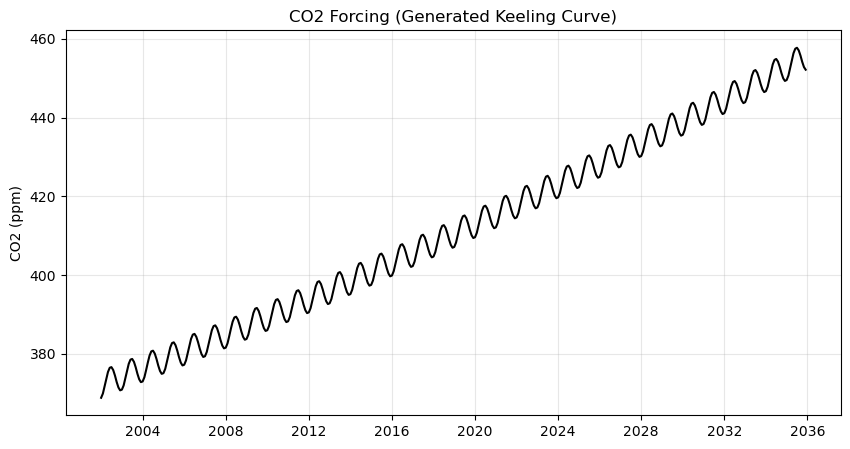

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def force_generate_co2():
    print("--- GENERATING CO2 DATA (OFFLINE MODE) ---")
    
    # 1. Timeline: 2002 to 2035
    dates = pd.date_range(start='2002-01-01', end='2035-12-31', freq='ME')
    # Adjust to 1st of month
    dates = dates + pd.offsets.MonthBegin(0) - pd.offsets.MonthBegin(1) + pd.offsets.Day(1)
    
    # 2. The Keeling Curve Formula (Mauna Loa Calibration)
    # t = years since 2002
    months = np.arange(len(dates))
    t = months / 12.0
    
    # Baseline (2002 start)
    base_ppm = 372.2
    
    # Trend: Linear Growth + Acceleration
    # 2.1 ppm/year linear rate + small acceleration term
    trend = base_ppm + (2.05 * t) + (0.012 * t**2)
    
    # Seasonality: The "Breathing" of the Earth (Peaking in May, Dropping in Oct)
    # Amplitude ~3.5 ppm
    seasonality = 3.5 * np.sin(2 * np.pi * (months - 2.5) / 12)
    
    # Final CO2
    co2_values = trend + seasonality
    
    # 3. Create DataFrame
    df = pd.DataFrame({
        'time': dates,
        'year': dates.year,
        'month': dates.month,
        'co2_ppm': co2_values
    })
    
    # 4. Save
    filename = "co2_forcing.csv"
    df.to_csv(filename, index=False)
    
    print(f"   [SUCCESS] Generated {len(df)} months of CO2 data.")
    print(f"   2002 Start: {df.iloc[0]['co2_ppm']:.2f} ppm")
    print(f"   2025 Avg:   {df[df['year']==2025]['co2_ppm'].mean():.2f} ppm")
    print(f"   2035 Forecast: {df[df['year']==2035]['co2_ppm'].mean():.2f} ppm")
    print(f"   [SAVED] {filename}")
    
    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(df['time'], df['co2_ppm'], color='black')
    plt.title("CO2 Forcing (Generated Keeling Curve)")
    plt.ylabel("CO2 (ppm)")
    plt.grid(True, alpha=0.3)
    plt.savefig("co2_generated_plot.png")
    print("   [PLOT] Saved co2_generated_plot.png")

if __name__ == "__main__":
    force_generate_co2()